Forward Propagation from scratch , general implementation and Vectorization for dense


In [2]:
import numpy as np 
import tensorflow as tf
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [3]:
def load_coffee_data():
    """ Creates a coffee roasting data set.
        roasting duration: 12-15 minutes is best
        temperature range: 175-260C is best
    """
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1,2)
    X[:,1] = X[:,1] * 4 + 11.5          # 12-15 min is best
    X[:,0] = X[:,0] * (285-150) + 150  # 350-500 F (175-260 C) is best
    Y = np.zeros(len(X))
    
    i=0
    for t,d in X:
        y = -3/(260-175)*t + 21
        if (t > 175 and t < 260 and d > 12 and d < 15 and d<=y ):
            Y[i] = 1
        else:
            Y[i] = 0
        i += 1

    return X, Y.reshape(-1,1)

X, Y = load_coffee_data()

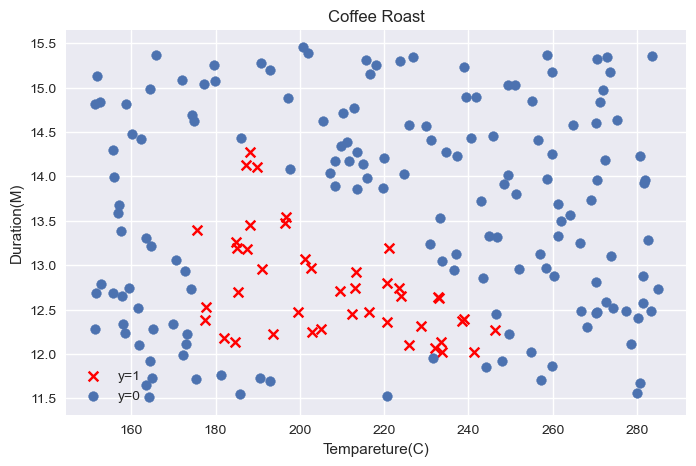

In [4]:
fig, ax = plt.subplots(1,1,figsize=(8,5))
pos = Y==1
neg = Y==0
pos = pos.reshape(-1)
neg = neg.reshape(-1)

ax.scatter(X[pos,0],X[pos,1],marker="x",c="r",label="y=1")
ax.scatter(X[neg,0],X[neg,1],marker="o",label="y=0")
ax.set_title("Coffee Roast")
ax.set_xlabel("Tempareture(C)")
ax.set_ylabel("Duration(M)")
plt.legend()
plt.show()

In [5]:
from tensorflow.keras.layers import Normalization 
norm = Normalization(axis=-1)
norm.adapt(X)
Xn = norm(X)

In [6]:
Xn

<tf.Tensor: shape=(200, 2), dtype=float32, numpy=
array([[-0.8345548 , -0.6528792 ],
       [ 1.0323056 , -1.3851453 ],
       [ 0.3089395 ,  0.8716251 ],
       [-1.0835686 , -1.5154841 ],
       [-0.7894309 ,  0.6194935 ],
       [ 0.18112455, -1.1790283 ],
       [-0.2568132 ,  0.6615495 ],
       [-0.29007566,  0.5335373 ],
       [ 1.5498862 ,  0.7103532 ],
       [-0.39534092, -1.047197  ],
       [-0.54960525,  0.1006532 ],
       [ 1.2923747 ,  1.0382426 ],
       [-0.64356774,  1.5651861 ],
       [-0.12749726,  0.7482604 ],
       [-1.356171  , -1.340383  ],
       [-1.0362515 ,  1.4242196 ],
       [ 0.5782223 ,  1.2993953 ],
       [ 0.45871648, -0.26986104],
       [ 0.0267812 ,  0.3926646 ],
       [ 1.194097  , -0.15769024],
       [ 1.2958571 ,  0.46452886],
       [ 1.0834197 ,  0.05453626],
       [ 0.6211483 , -0.5091947 ],
       [ 0.04789633, -0.94450104],
       [-1.3781422 , -1.5741245 ],
       [ 0.6530098 , -0.09301733],
       [ 1.3144174 ,  1.24958   ],
     

In [7]:
def sigmoid(z):
    g = 1/(1 + np.exp(-z))
    return g
    

In [8]:
def my_dense(a_in, W, b):
    units = W.shape[1]
    a_out = np.zeros(units)
    for j in range(units):
        w = W[:,j]
        z = np.dot(a_in, w) + b[j]
        a_out[j] = sigmoid(z)
    return (a_out)

In [9]:
def my_sequential(x, W1, b1, W2, b2):
    a1 = my_dense(x, W1, b1)
    a2 = my_dense(a1, W2, b2)
    return (a2)

In [10]:
def my_predict(X, W1, b1, W2, b2):
    m = X.shape[0]
    p = np.zeros((m,1))
    for i in range(m):
        p[i,0] = my_sequential(X[i], W1, b1, W2, b2)
    return (p)

In [11]:
W1_tmp = np.array( [[-8.93,  0.29, 12.9 ], [-0.1,  -7.32, 10.81]] )
b1_tmp = np.array( [-9.82, -9.28,  0.96] )
W2_tmp = np.array( [[-31.18], [-27.59], [-32.56]] )
b2_tmp = np.array( [15.41] )

X_test = np.array([
    [200,13.9],  # postive example
    [200,17]])   # negative example
X_test_norm = norm(X_test)

pred = my_predict(X_test_norm, W1_tmp, b1_tmp, W2_tmp, b2_tmp)

predict = (pred >= 0.5).astype(int)
print(predict)

[[1]
 [0]]


C:\Users\Taiyob Ali\AppData\Local\Temp\ipykernel_9200\2786066927.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p[i,0] = my_sequential(X[i], W1, b1, W2, b2)


Vectorization

In [13]:
XT = np.array([[200, 17]])
W = np.array([[1, -3, 5],
              [-2, 4, -6]])
B = np.array([[-1, 1, 2]])

def dense(XT, W, B):
    Z = np.matmul(XT, W) + B 
    a_out = sigmoid(Z)
    return a_out 
A = dense(XT, W, B)
predict = (A >= 0.5).astype(int)
print(predict)

[[1 0 1]]
